In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
from glob import glob
import numpy as np

print("Libraries imported successfully")

Libraries imported successfully


In [14]:
# Define the dataset path
DATASET_PATH = "/home/rcd/Desktop/Workspace/remote-control/analysis"

# Search for all WAN data files recursively
wan_data_files = glob(os.path.join(DATASET_PATH, "**/*wan_data*.json"), recursive=True)

print(f"Found {len(wan_data_files)} WAN data files:")

# Load all WAN data into a dictionary
wan_datasets = {}

for file_path in wan_data_files:
    # Extract folder name as title (parent directory name)
    folder_name = os.path.basename(os.path.dirname(file_path))
    
    # Load the JSON data
    with open(file_path, 'r') as f:
        data = json.load(f)
    
    # Extract signal strength data from wanData array
    signal_data = []
    for entry in data.get('wanData', []):
        lte_data = entry.get('data', {}).get('lte', {})
        if lte_data:
            signal_data.append({
                'sequence': entry.get('id'),
                'timestamp': entry.get('timestamp'),
                'rsrp': float(lte_data.get('lRsrp', 0)) if lte_data.get('lRsrp') else None,
                'rsrq': float(lte_data.get('lRsrq', 0)) if lte_data.get('lRsrq') else None,
                'sinr': float(lte_data.get('lSinr', 0)) if lte_data.get('lSinr') else None,
                'rssi': float(lte_data.get('lRssi', 0)) if lte_data.get('lRssi') else None
            })
    
    # Convert to DataFrame
    df = pd.DataFrame(signal_data)
    wan_datasets[folder_name] = df
    print(f"  - {folder_name}: {len(df)} records")

print(f"\nLoaded {len(wan_datasets)} datasets successfully!")

Found 5 WAN data files:
  - Scenario_LongRun_Test_01: 611 records
  - Scenario_02_Test_01: 327 records
  - Scenario_02_Test_02: 323 records
  - Scenario_01_Test_02: 253 records
  - Scenario_01_Test_01: 260 records

Loaded 5 datasets successfully!


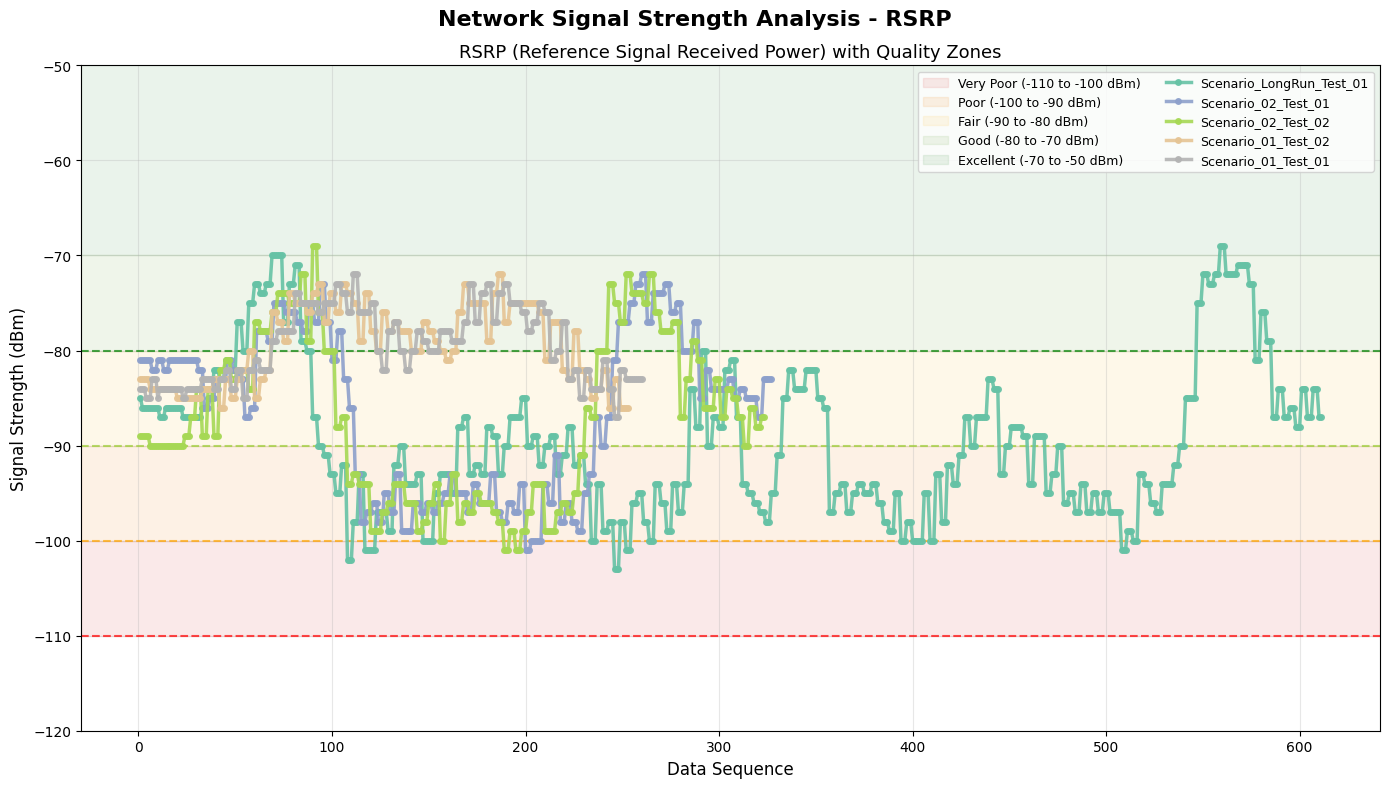


RSRP graph with quality zones generated successfully!


In [16]:
# Create figure for RSRP signal strength (Combined)
fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle('Network Signal Strength Analysis - RSRP', fontsize=16, fontweight='bold')

# Define RSRP quality zones
quality_zones = [
    (-110, -100, 'Very Poor', '#d32f2f', 0.1),
    (-100, -90, 'Poor', '#f57c00', 0.1),
    (-90, -80, 'Fair', '#fbc02d', 0.1),
    (-80, -70, 'Good', '#689f38', 0.1),
    (-70, -50, 'Excellent', '#388e3c', 0.1)
]

# Add quality zone backgrounds
for lower, upper, label, color, alpha in quality_zones:
    ax.axhspan(lower, upper, alpha=alpha, color=color, label=f'{label} ({lower} to {upper} dBm)')

# Add horizontal reference lines
ax.axhline(y=-80, color='green', linestyle='--', linewidth=1.5, alpha=0.7)
ax.axhline(y=-90, color='yellowgreen', linestyle='--', linewidth=1.5, alpha=0.7)
ax.axhline(y=-100, color='orange', linestyle='--', linewidth=1.5, alpha=0.7)
ax.axhline(y=-110, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

# Plot the data
colors = plt.cm.Set2(np.linspace(0, 1, len(wan_datasets)))

for color_idx, (dataset_name, df) in enumerate(wan_datasets.items()):
    # Filter out None values for RSRP
    valid_data = df[['sequence', 'rsrp']].dropna()
    
    if not valid_data.empty:
        ax.plot(valid_data['sequence'], valid_data['rsrp'], 
               label=dataset_name, 
               linewidth=2.5, 
               marker='o', 
               markersize=4,
               alpha=0.9,
               color=colors[color_idx])

ax.set_xlabel('Data Sequence', fontsize=12)
ax.set_ylabel('Signal Strength (dBm)', fontsize=12)
ax.set_title('RSRP (Reference Signal Received Power) with Quality Zones', fontsize=13)
ax.legend(loc='best', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)

# Set y-axis limits to show all zones
ax.set_ylim(-120, -50)

plt.tight_layout()
plt.show()

print("\nRSRP graph with quality zones generated successfully!")

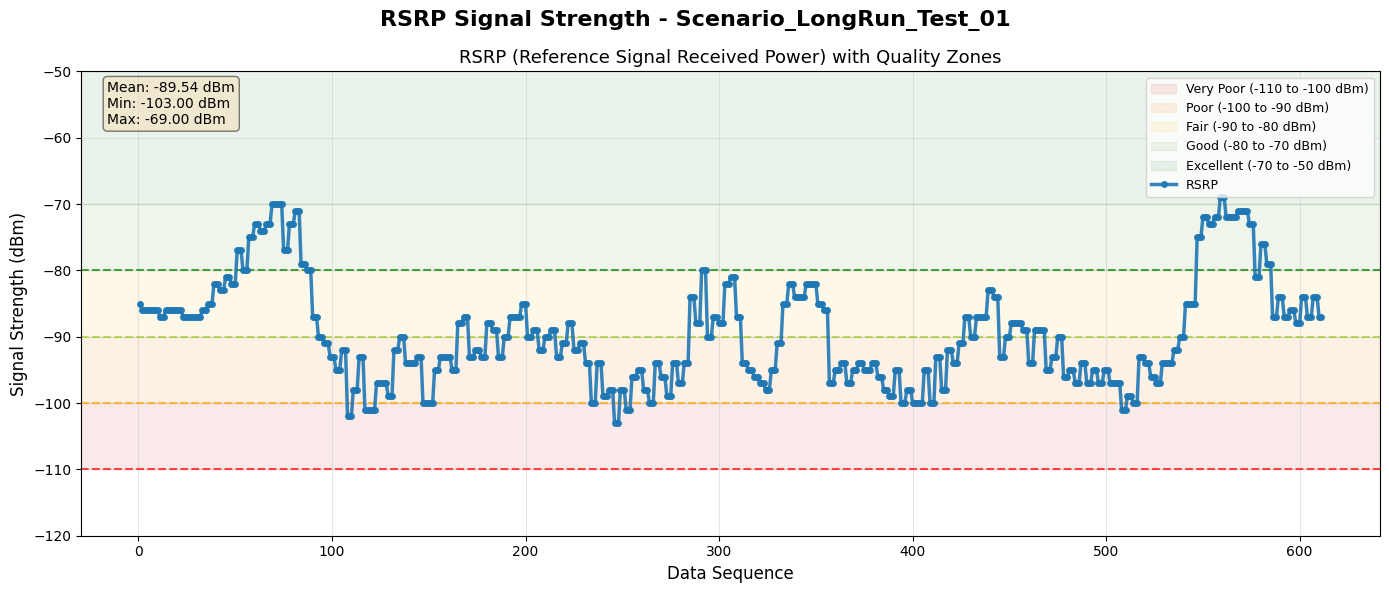


Generated graph for: Scenario_LongRun_Test_01


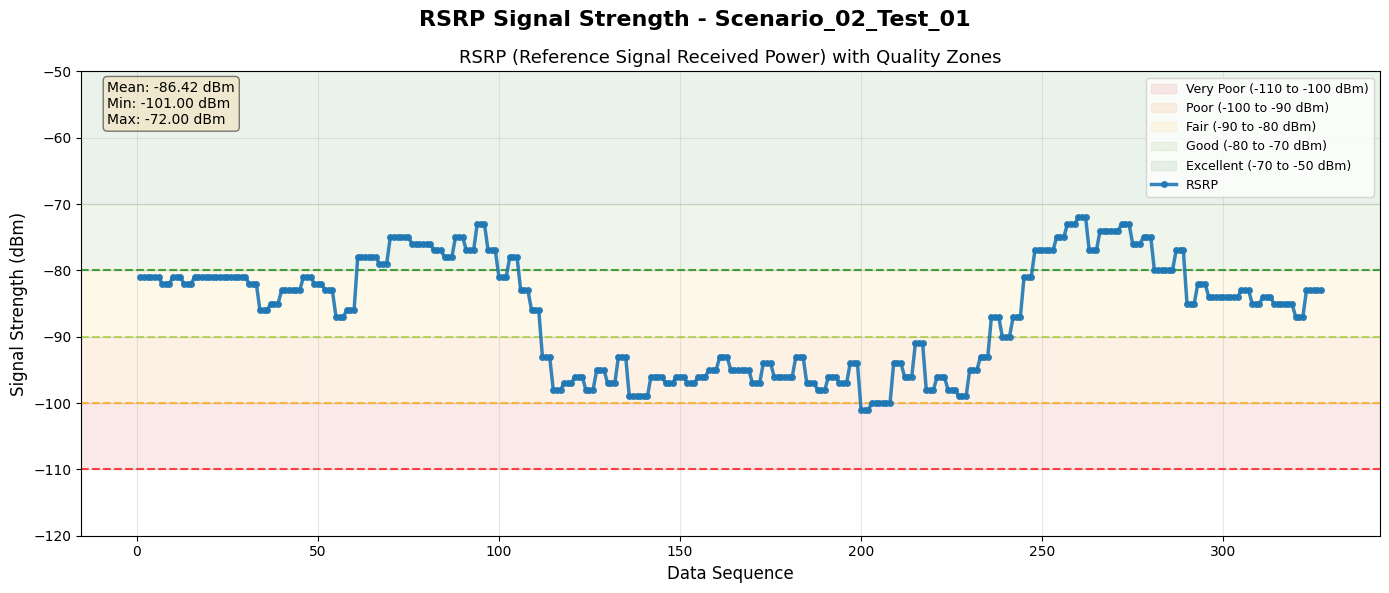


Generated graph for: Scenario_02_Test_01


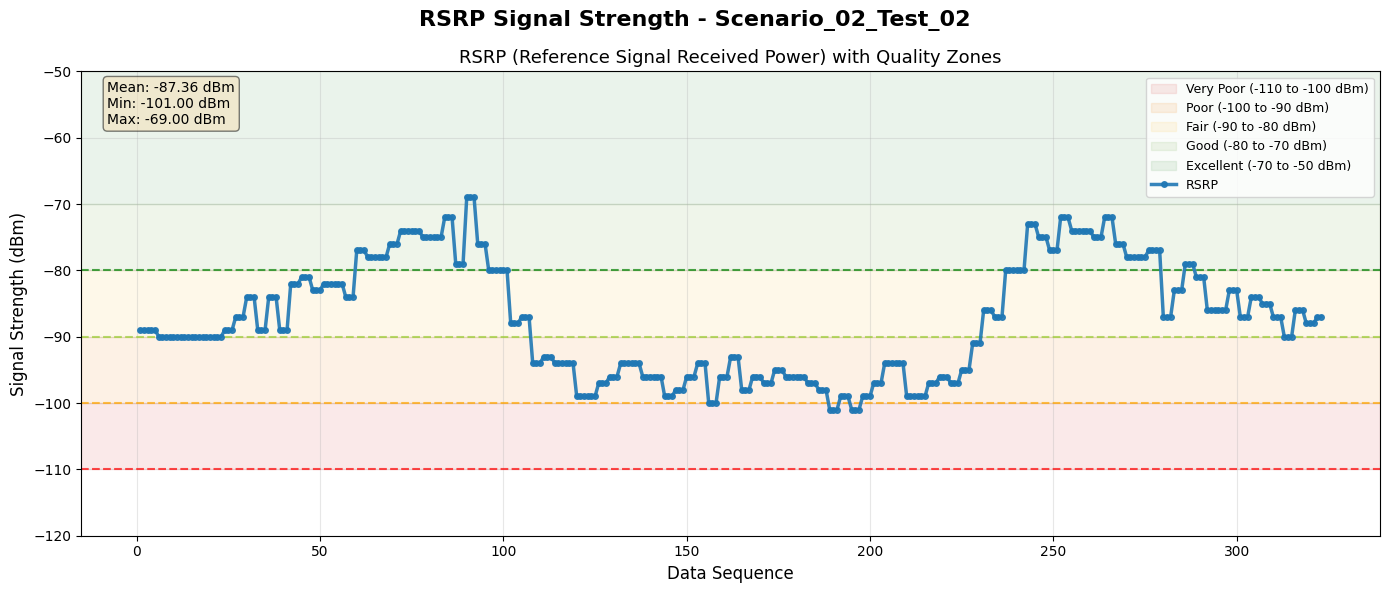


Generated graph for: Scenario_02_Test_02


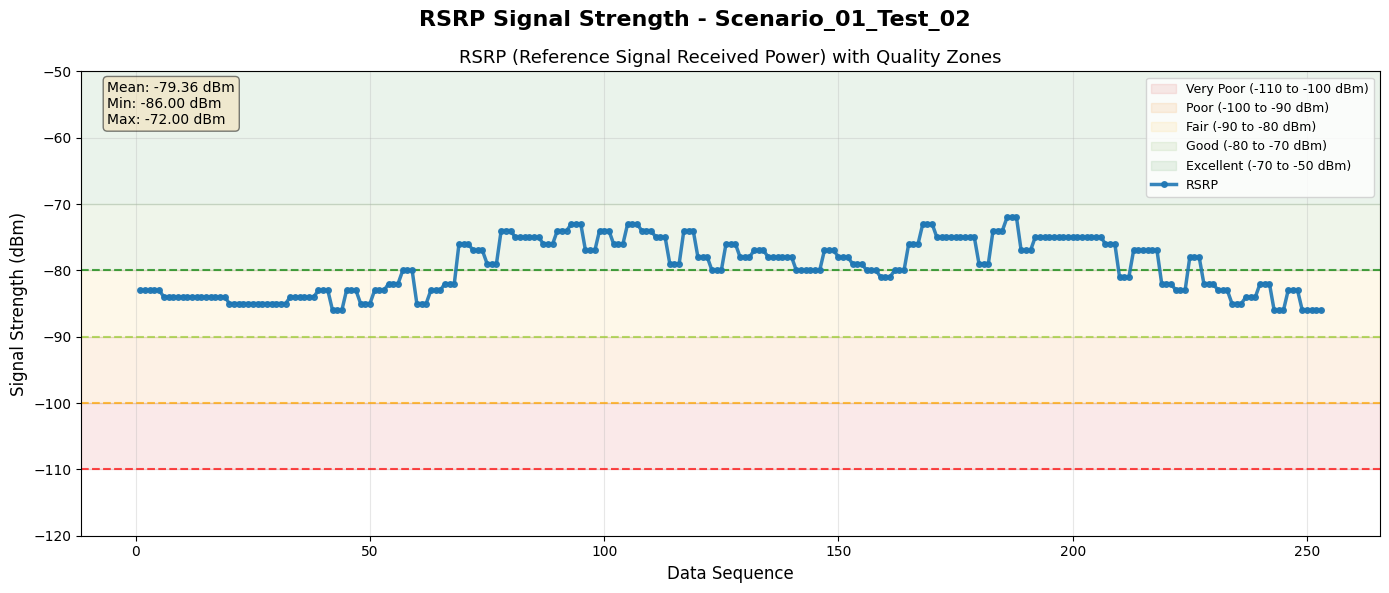


Generated graph for: Scenario_01_Test_02


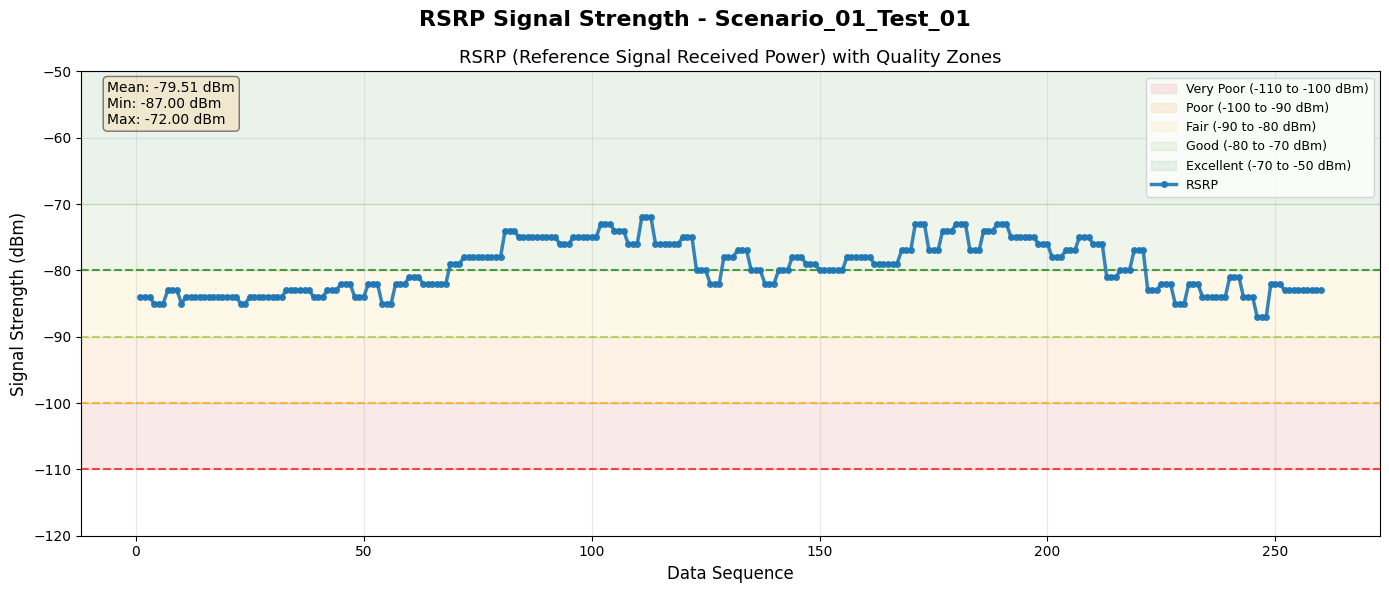


Generated graph for: Scenario_01_Test_01

All individual RSRP graphs generated successfully!


In [17]:
# Generate individual RSRP graphs for each WAN data file
quality_zones = [
    (-110, -100, 'Very Poor', '#d32f2f', 0.1),
    (-100, -90, 'Poor', '#f57c00', 0.1),
    (-90, -80, 'Fair', '#fbc02d', 0.1),
    (-80, -70, 'Good', '#689f38', 0.1),
    (-70, -50, 'Excellent', '#388e3c', 0.1)
]

# Create individual plots for each dataset
for dataset_name, df in wan_datasets.items():
    fig, ax = plt.subplots(figsize=(14, 6))
    fig.suptitle(f'RSRP Signal Strength - {dataset_name}', fontsize=16, fontweight='bold')
    
    # Add quality zone backgrounds
    for lower, upper, label, color, alpha in quality_zones:
        ax.axhspan(lower, upper, alpha=alpha, color=color, label=f'{label} ({lower} to {upper} dBm)')
    
    # Add horizontal reference lines
    ax.axhline(y=-80, color='green', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.axhline(y=-90, color='yellowgreen', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.axhline(y=-100, color='orange', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.axhline(y=-110, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    
    # Filter out None values for RSRP
    valid_data = df[['sequence', 'rsrp']].dropna()
    
    if not valid_data.empty:
        ax.plot(valid_data['sequence'], valid_data['rsrp'], 
               linewidth=2.5, 
               marker='o', 
               markersize=4,
               alpha=0.9,
               color='#1f77b4',
               label='RSRP')
        
        # Add statistics text
        mean_rsrp = valid_data['rsrp'].mean()
        min_rsrp = valid_data['rsrp'].min()
        max_rsrp = valid_data['rsrp'].max()
        
        stats_text = f'Mean: {mean_rsrp:.2f} dBm\nMin: {min_rsrp:.2f} dBm\nMax: {max_rsrp:.2f} dBm'
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
               fontsize=10, verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.set_xlabel('Data Sequence', fontsize=12)
    ax.set_ylabel('Signal Strength (dBm)', fontsize=12)
    ax.set_title('RSRP (Reference Signal Received Power) with Quality Zones', fontsize=13)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-120, -50)
    
    plt.tight_layout()
    plt.show()
    print(f"\nGenerated graph for: {dataset_name}")

print("\nAll individual RSRP graphs generated successfully!")